### Importação das bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from xgboost import XGBClassifier  

from sklearn.ensemble  import RandomForestClassifier

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
    )




from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    precision_recall_curve,
    roc_curve,
    roc_auc_score,
    auc,
    confusion_matrix,
    classification_report,
    precision_score, 
    recall_score, 
    f1_score,
    fbeta_score
)


from ucimlrepo import fetch_ucirepo

# Carregar dataset
dataset = fetch_ucirepo(id=350)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

### remoçao dados duplicados 

In [3]:
dados = X.copy()
dados["Y"] = y.iloc[:, 0]
dados = dados.drop_duplicates()

dados_depois = len(dados)

print("Registros depois:", dados_depois)

X = dados.drop(columns=["Y"])
y = dados["Y"]

Registros depois: 29965


### tratando de X3 (nivel de educaçao)

In [4]:
X["X3"] = X["X3"].replace({
    0: 4,
    5: 4,
    6: 4
})
print(X["X3"].value_counts().sort_index())

X3
1    10563
2    14019
3     4915
4      468
Name: count, dtype: int64


### tratando dados de X4 (estado civil)

In [5]:
X["X4"] = X["X4"].replace({
    0: 3,
})

print(X["X4"].value_counts().sort_index())

X4
1    13643
2    15945
3      377
Name: count, dtype: int64


### preprocessar colunas

* X1 numerica continua - scaling
* X2-categorica nominal -one hot encoding
* X3-categorica ordinal - Ordinal Encoding
* X4-categorica nominal -one hot encoding
* X5-numericas discreta  - Scaling
* X6 - X11 categorica ordinal - Ordinal Encoding
* X12 - X17 numerica continua -scaling
* X18 - X23 numerica continua -scaling

In [6]:
# Variáveis numéricas
features_numericas = [
    "X1",
    "X5",
    "X6", "X7", "X8", "X9", "X10", "X11",
    "X12", "X13", "X14", "X15", "X16", "X17",
    "X18", "X19", "X20", "X21", "X22", "X23"
]

# Categóricas nominais
features_nominais = [
    "X2",
    "X4"
]

# Categórica ordinal
features_ordinais = [
    "X3"
]

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            StandardScaler(),
            features_numericas
        ),
        (
            "nominais",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            features_nominais
        ),
        (
            "ordinais",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ),
            features_ordinais
        )
    ]
)

### Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:")
print(y_train.value_counts(normalize=True))

print("\nTeste:")
print(y_test.value_counts(normalize=True))

Treino:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64

Teste:
Y
0    0.778742
1    0.221258
Name: proportion, dtype: float64


### funçao de busca de hiperparametros

In [8]:
def realizar_busca_hiperparametros(modelo, hiperparametros, X_train, y_train):
    # Mudança para 'roc_auc' para garantir que os parâmetros otimizem o modelo de forma global
    grid_search = GridSearchCV(
        estimator=modelo,
        param_grid=hiperparametros,
        scoring='roc_auc', 
        cv=5,
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)

    return grid_search.best_estimator_, grid_search.best_params_, grid_search.best_score_

### funçao de busca de busca de melhor threshold

In [9]:
def melhor_threshold_via_cv(modelo, X_train, y_train, cv, beta=2):
    y_prob_cv = cross_val_predict(modelo, X_train, y_train, cv=cv, method="predict_proba")[:, 1]
    
    thresholds = np.arange(0.15, 0.55, 0.01)
    resultados = []
    for t in thresholds:
        y_pred_t = (y_prob_cv >= t).astype(int)
        resultados.append({
            "threshold": t,
            "fbeta": fbeta_score(y_train, y_pred_t, beta=beta)
        })
    return pd.DataFrame(resultados)
    

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### funçao de avaliar modelo

In [10]:
def avaliar_modelo(y_true, y_pred):

    print("Matriz de confusão:")
    print(confusion_matrix(y_true, y_pred))

    print(f"\nPrecision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1:        {f1_score(y_true, y_pred):.3f}")
    print(f"F2:        {fbeta_score(y_true, y_pred, beta=2):.3f}")

### funçao de agrupamento de features

In [11]:
def identificar_grupo(feature):

    # Remove o nome do transformador
    # Exemplo:
    # numericas__X6 -> X6
    # ordinais__X3 -> X3
    # nominais__X2_1 -> X2_1

    feature = feature.split("__")[-1]

    # Limite de crédito
    if feature == "X1":
        return "Limite de crédito"

    # Variáveis demográficas
    elif (
        feature.startswith("X2_")
        or feature == "X3"
        or feature.startswith("X4_")
        or feature == "X5"
    ):
        return "Demográficas"

    # Histórico de pagamentos
    elif feature in ["X6", "X7", "X8", "X9", "X10", "X11"]:
        return "Histórico de pagamento"

    # Valores das faturas
    elif feature in ["X12", "X13", "X14", "X15", "X16", "X17"]:
        return "Valores das faturas"

    # Pagamentos anteriores
    elif feature in ["X18", "X19", "X20", "X21", "X22", "X23"]:
        return "Pagamentos anteriores"

    else:
        return "Outros"



# LogisticRegressio


In [68]:
modelo_logistico = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

### treino e previsões

In [69]:
modelo_logistico.fit(
    X_train,
    y_train
)

y_pred = modelo_logistico.predict(X_test)
y_prob = modelo_logistico.predict_proba(X_test)[:, 1]
modelo_logistico.score(X_test, y_test)

print("Previsões:")
print(pd.Series(y_pred).value_counts())

print("\nValores reais:")
print(y_test.value_counts())

cm = confusion_matrix(y_test, y_pred)

print(cm)


Previsões:
0    5538
1     455
Name: count, dtype: int64

Valores reais:
Y
0    4667
1    1326
Name: count, dtype: int64
[[4542  125]
 [ 996  330]]


In [70]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4667
           1       0.73      0.25      0.37      1326

    accuracy                           0.81      5993
   macro avg       0.77      0.61      0.63      5993
weighted avg       0.80      0.81      0.78      5993

ROC-AUC: 0.7160981713975828


### thresholds

In [71]:


thresholds = [0.50, 0.45, 0.40, 0.35, 0.30, 0.25, 0.20]

for threshold in thresholds:

    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.50 | Precision: 0.725 | Recall: 0.249 | F1: 0.371
Threshold: 0.45 | Precision: 0.683 | Recall: 0.318 | F1: 0.434
Threshold: 0.40 | Precision: 0.630 | Recall: 0.367 | F1: 0.463
Threshold: 0.35 | Precision: 0.598 | Recall: 0.411 | F1: 0.487
Threshold: 0.30 | Precision: 0.554 | Recall: 0.449 | F1: 0.496
Threshold: 0.25 | Precision: 0.453 | Recall: 0.553 | F1: 0.498
Threshold: 0.20 | Precision: 0.331 | Recall: 0.689 | F1: 0.447


### melhores hiperparametros


In [72]:
hiperparametros_LR = {
    "modelo__C": [0.01, 0.1, 1, 10],
    "modelo__solver": ["saga"],
    "modelo__class_weight": [None, "balanced"],
    "modelo__max_iter": [1000]
}


print("Iniciando busca de hiperparâmetros...")
melhor_modelo, melhores_parametros, melhor_score = realizar_busca_hiperparametros(modelo_logistico, hiperparametros_LR, X_train, y_train)

print(f"\nMelhor ROC-AUC encontrado: {melhor_score:.3f}")
print(f"Melhores parâmetros: {melhores_parametros}")

modelo_logistico = melhor_modelo

Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

Melhor ROC-AUC encontrado: 0.725
Melhores parâmetros: {'modelo__C': 1, 'modelo__class_weight': 'balanced', 'modelo__max_iter': 1000, 'modelo__solver': 'saga'}


### melhor threshold para hiperparametros

In [ ]:


y_prob = modelo_logistico.predict_proba(X_test)[:, 1]


df_thresholds_rf = melhor_threshold_via_cv(modelo_logistico, X_train, y_train, cv)


melhor_threshold_val = df_thresholds_rf.loc[df_thresholds_rf["fbeta"].idxmax()]["threshold"]

print("\n--- Logistic Regression Ajustado ---")

print(f"\nMelhor Threshold encontrado no Treino: {melhor_threshold_val:.2f}")

y_pred_otimo = (y_prob >= melhor_threshold_val).astype(int)


avaliar_modelo(y_test, y_pred_otimo)


Melhor Threshold encontrado no Treino: 0.31
Matriz de confusão:
[[1145 3522]
 [ 158 1168]]

Precision: 0.249
Recall:    0.881
F1:        0.388
F2:        0.584


### precision reacal curve e curva roc

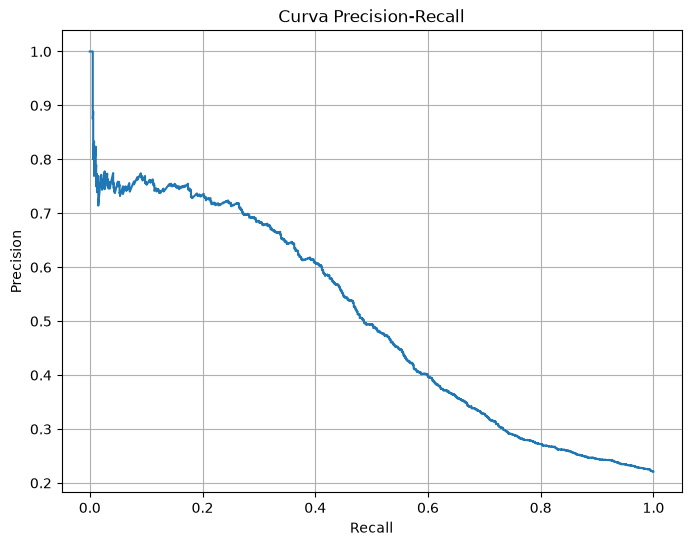

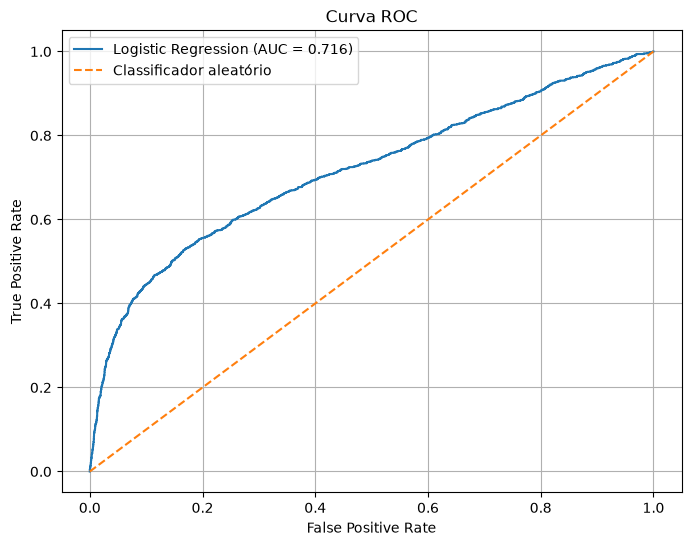

In [75]:

precision, recall, thresholds_pr = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall")

plt.grid()
plt.show()


fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_prob
)



roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Classificador aleatório"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC")

plt.legend()
plt.grid()

plt.show()

# Random Forest

In [76]:



modelo_random_forest = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42
            )
        )
    ]
)

modelo_random_forest.fit(
    X_train,
    y_train
)

y_pred = modelo_random_forest.predict(X_test)
y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]
modelo_random_forest.score(X_test, y_test)

print("Previsões:")
print(pd.Series(y_pred).value_counts())

print("\nValores reais:")
print(y_test.value_counts())

cm = confusion_matrix(y_test, y_pred)

print(cm)

          


Previsões:
0    5243
1     750
Name: count, dtype: int64

Valores reais:
Y
0    4667
1    1326
Name: count, dtype: int64
[[4383  284]
 [ 860  466]]


In [77]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]



              precision    recall  f1-score   support

           0       0.84      0.94      0.88      4667
           1       0.62      0.35      0.45      1326

    accuracy                           0.81      5993
   macro avg       0.73      0.65      0.67      5993
weighted avg       0.79      0.81      0.79      5993

ROC-AUC: 0.7540930334323244


## analise das features do Random Forest

In [78]:
modelo_rf = modelo_random_forest.named_steps["modelo"]

nomes_features = (
    modelo_random_forest
    .named_steps["preprocessamento"]
    .get_feature_names_out()
)

importancias = modelo_rf.feature_importances_

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importance": importancias
})

df_importancia = df_importancia.sort_values(
    by="importance",
    ascending=False
)

display(df_importancia.head(20))

,feature,importance
2,numericas__X6,0.100191
1,numericas__X5,0.064353
8,numericas__X12,0.060056
0,numericas__X1,0.058165
9,numericas__X13,0.052749
14,numericas__X18,0.050703
10,numericas__X14,0.050325
13,numericas__X17,0.049466
12,numericas__X16,0.049062
11,numericas__X15,0.048753


Importância das variáveis por grupo:


,grupo,importance
0,Valores das faturas,0.310411
1,Pagamentos anteriores,0.275639
2,Histórico de pagamento,0.235241
3,Demográficas,0.120544
4,Limite de crédito,0.058165


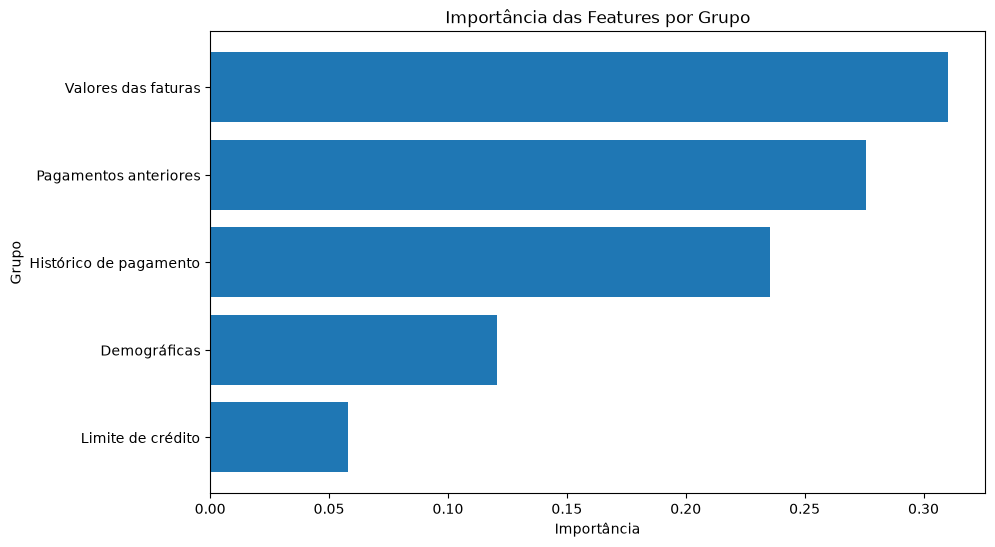

In [ ]:



df_importancia["grupo"] = (
    df_importancia["feature"]
    .apply(identificar_grupo)
)



df_importancia_grupos = (
    df_importancia
    .groupby("grupo")["importance"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)



print("Importância das variáveis por grupo:")

display(df_importancia_grupos)

plt.figure(figsize=(10, 6))

plt.barh(
    df_importancia_grupos["grupo"][::-1],
    df_importancia_grupos["importance"][::-1]
)

plt.xlabel("Importância")
plt.ylabel("Grupo")
plt.title("Importância das Features por Grupo")

plt.show()

## Análise da importância das features

A análise da importância das variáveis do Random Forest mostrou que as informações relacionadas ao comportamento financeiro dos clientes possuem maior relevância para as previsões. O grupo de valores das faturas apresentou importância agregada de 31,04%, seguido pelos pagamentos anteriores, com 27,56%, e pelo histórico de pagamento, com 23,52%. Em conjunto, essas três categorias representam aproximadamente 82,13% da importância atribuída pelo modelo.

As variáveis demográficas apresentaram importância agregada de 12,05%, enquanto o limite de crédito representou 5,82%. Individualmente, a variável X6, correspondente ao histórico de pagamento mais recente, apresentou a maior importância, com aproximadamente 10,02%.

Esses resultados sugerem que o modelo utiliza predominantemente informações relacionadas ao comportamento financeiro passado para realizar suas previsões, enquanto as características demográficas e o limite de crédito apresentam menor importância relativa.

## hiperparâmetros random forest

In [80]:

hiperparametros = {
    "modelo__n_estimators": [100, 200, 300],
    "modelo__max_depth": [None, 10, 20, 30],
    "modelo__max_features": ["sqrt", "log2"],
    "modelo__class_weight": [None, "balanced"]
}


print("Iniciando busca de hiperparâmetros...")
melhor_modelo_rf, melhores_parametros, melhor_score = realizar_busca_hiperparametros(modelo_random_forest, hiperparametros, X_train, y_train)

print(f"\nMelhor ROC-AUC encontrado: {melhor_score:.3f}")
print(f"Melhores parâmetros: {melhores_parametros}")

Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

Melhor ROC-AUC encontrado: 0.782
Melhores parâmetros: {'modelo__class_weight': None, 'modelo__max_depth': 10, 'modelo__max_features': 'sqrt', 'modelo__n_estimators': 200}


## melhor threshold para melhores parametros  do random forest


In [ ]:
modelo_random_forest = melhor_modelo_rf

y_prob = modelo_random_forest.predict_proba(X_test)[:, 1]



df_thresholds_rf = melhor_threshold_via_cv(modelo_random_forest, X_train, y_train, cv)


melhor_threshold_val = df_thresholds_rf.loc[df_thresholds_rf["fbeta"].idxmax()]["threshold"]

print("\n--- Random Forest Ajustado ---")
print(f"\nMelhor Threshold encontrado no Treino: {melhor_threshold_val:.2f}")


y_pred_otimo = (y_prob >= melhor_threshold_val).astype(int)


avaliar_modelo(y_test, y_pred_otimo)


Melhor Threshold encontrado no Treino: 0.15
Matriz de confusão:
[[2776 1891]
 [ 314 1012]]

Precision: 0.349
Recall:    0.763
F1:        0.479
F2:        0.617


# Modelo de Gradient Boosting

In [12]:

# Construção do Pipeline
modelo_xgb = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        (
            "modelo",
            XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=5,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

# Treinamento
modelo_xgb.fit(X_train, y_train)

# Probabilidades no Teste
y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Teste de Thresholds
thresholds_testados = np.arange(0.15, 0.55, 0.05)
resultados_xgb = []

for thresh in thresholds_testados:
    y_pred_thresh = (y_prob_xgb >= thresh).astype(int)
    resultados_xgb.append({
        "threshold": round(thresh, 2),
        "precision": precision_score(y_test, y_pred_thresh),
        "recall": recall_score(y_test, y_pred_thresh),
        "f1": f1_score(y_test, y_pred_thresh)
    })

df_xgb = pd.DataFrame(resultados_xgb)
display(df_xgb)

print(f"ROC-AUC Teste (XGBoost): {roc_auc_score(y_test, y_prob_xgb):.3f}")

# 1. Calculando a proporção de classes no treino para balanço automático
qtd_negativos = (y_train == 0).sum()
qtd_positivos = (y_train == 1).sum()
peso_classe = qtd_negativos / qtd_positivos

,threshold,precision,recall,f1
0,0.15,0.358188,0.757164,0.486316
1,0.20,0.426556,0.661388,0.518628
2,0.25,0.488764,0.590498,0.534836
3,0.30,0.537757,0.531674,0.534699
4,0.35,0.582407,0.474359,0.522860
5,0.40,0.622416,0.431373,0.509577
6,0.45,0.640147,0.394419,0.488101
7,0.50,0.658872,0.361237,0.466634


ROC-AUC Teste (XGBoost): 0.774


 ## melhores hiperparametros XGBoost

In [13]:
hiperparametros_xgb = {
    "modelo__n_estimators": [100, 200],
    "modelo__max_depth": [3, 5],
    "modelo__learning_rate": [0.05, 0.1],
    "modelo__scale_pos_weight": [1, peso_classe],
}


print("Iniciando busca de hiperparâmetros...")
melhor_modelo_xgb, melhores_parametros, melhor_score = realizar_busca_hiperparametros(modelo_xgb, hiperparametros_xgb, X_train, y_train)

print(f"\nMelhor ROC-AUC encontrado: {melhor_score:.3f}")
print(f"Melhores parâmetros: {melhores_parametros}")
modelo_xgb = melhor_modelo_xgb

Iniciando busca de hiperparâmetros...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

Melhor ROC-AUC encontrado: 0.784
Melhores parâmetros: {'modelo__learning_rate': 0.05, 'modelo__max_depth': 3, 'modelo__n_estimators': 200, 'modelo__scale_pos_weight': np.float64(3.519607843137255)}


### threshold para melhores hiperparametros

In [14]:


print(f"Proporção de Adimplentes / Inadimplentes: {peso_classe:.2f}")

modelo_xgb.fit(X_train, y_train)


y_prob_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

df_thresholds_rf = melhor_threshold_via_cv(modelo_xgb, X_train, y_train, cv)


melhor_threshold_val = df_thresholds_rf.loc[df_thresholds_rf["fbeta"].idxmax()]["threshold"]

# Pega a melhor linha de F1
melhor_xgb = df_xgb.loc[df_xgb["f1"].idxmax()]

print("\n--- XGBoost Ajustado ---")
print(f"ROC-AUC Teste: {roc_auc_score(y_test, y_prob_xgb):.3f}")


y_pred_otimo = (y_prob_xgb >= melhor_threshold_val).astype(int)
print(f"--- Relatório de Classificação (Threshold Otimizado: {melhor_threshold_val:.2f}) ---")

avaliar_modelo(y_test, y_pred_otimo)

Proporção de Adimplentes / Inadimplentes: 3.52

--- XGBoost Ajustado ---
ROC-AUC Teste: 0.775
--- Relatório de Classificação (Threshold Otimizado: 0.34) ---
Matriz de confusão:
[[2394 2273]
 [ 232 1094]]

Precision: 0.325
Recall:    0.825
F1:        0.466
F2:        0.631


# comparaçao entre modelos

Os três modelos foram submetidos ao mesmo processo de otimização e tiveram seus thresholds selecionados com base no F2-score, buscando priorizar a identificação da classe inadimplente.
A priorização do recall aumentou a quantidade de clientes classificados como potenciais inadimplentes, resultando em uma redução da precision. Esse comportamento é particularmente evidente na Regressão Logística, que alcançou recall de 0,881, porém apresentou 3.522 falsos positivos.

### Comparação dos modelos otimizados

| Métrica | Regressão Logística | Random Forest | XGBoost |
| :--- | :---: | :---: | :---: |
| **ROC-AUC** | 0,716 | 0,770 | **0,775** |
| **Threshold** | 0,31 | 0,15 | 0,34 |
| **Precision** | 0,249 | **0,349** | 0,325 |
| **Recall** | **0,881** | 0,763 | 0,825 |
| **F1-Score** | 0,388 | **0,479** | 0,466 |
| **F2-Score** | 0,584 | 0,617 | **0,631** |

### Matrizes de confusão

| Modelo | TN | FP | FN | TP |
| :--- | ---: | ---: | ---: | ---: |
| **Regressão Logística** | 1.145 | 3.522 | 158 | 1.168 |
| **Random Forest** | 2.776 | 1.891 | 314 | 1.012 |
| **XGBoost** | 2.394 | 2.273 | 232 | 1.094 |

Considerando que o objetivo do projeto é priorizar a identificação de clientes inadimplentes, o XGBoost foi selecionado como modelo final. Embora a Regressão Logística tenha apresentado o maior recall, o XGBoost obteve o maior F2-score e ROC-AUC, apresentando uma relação mais equilibrada entre capacidade de identificação dos inadimplentes e quantidade de falsos positivos.

# analise do XGBoost

## analise das features

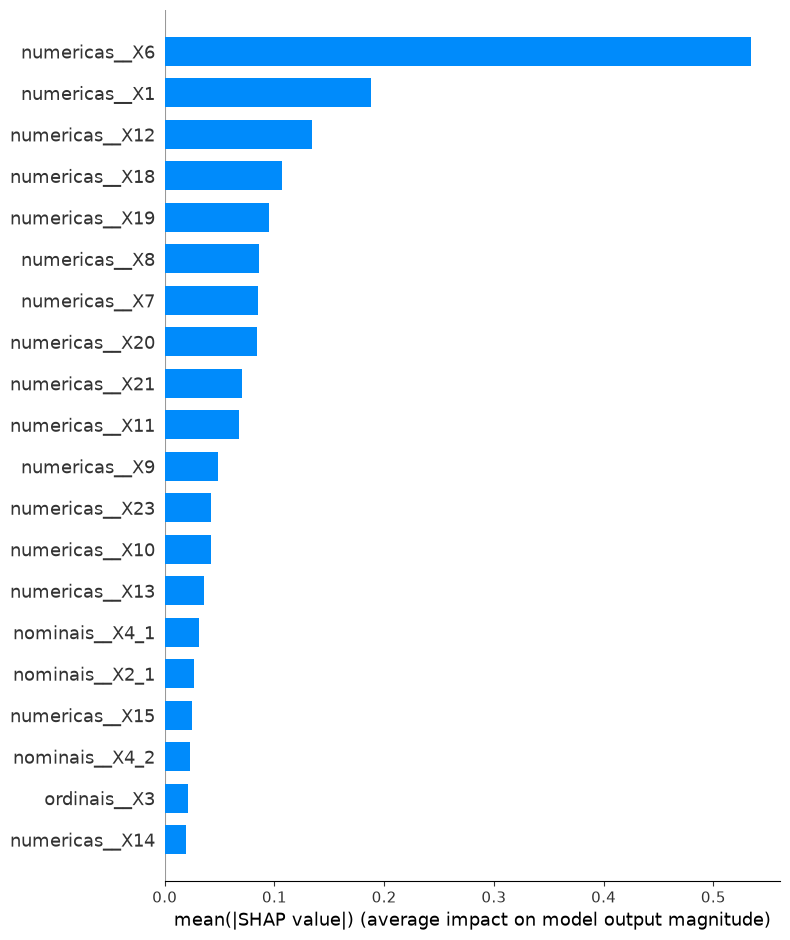

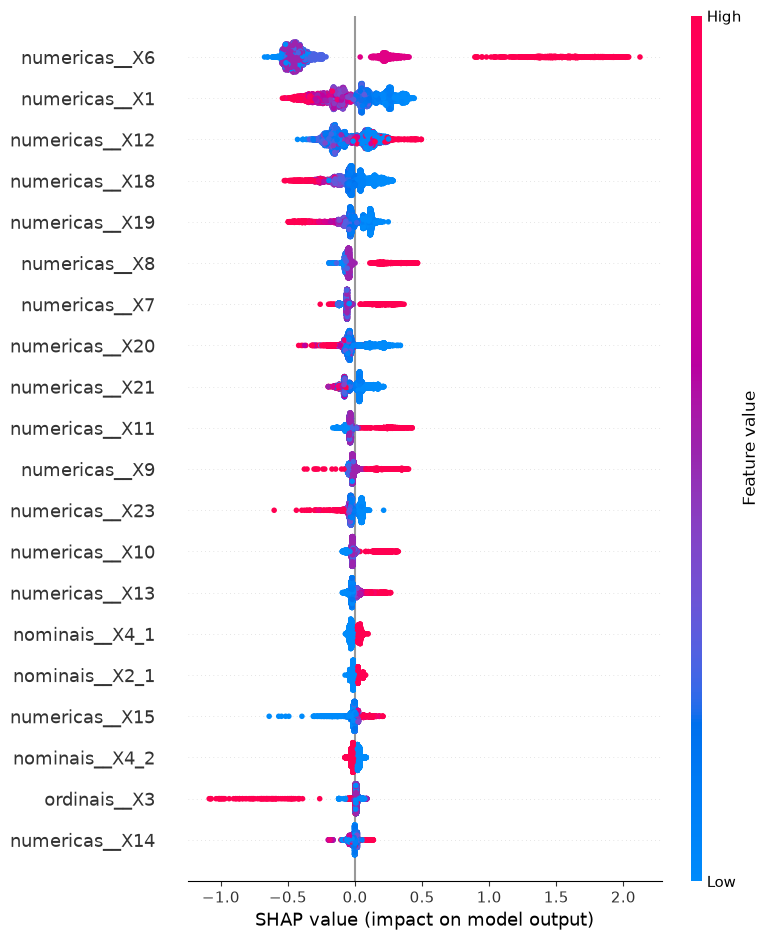

In [17]:
modelo = modelo_xgb.named_steps["modelo"]
preprocessador = modelo_xgb.named_steps["preprocessamento"]

X_train_transformado = preprocessador.transform(X_train)
X_test_transformado = preprocessador.transform(X_test)

nomes_features = preprocessador.get_feature_names_out()

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test_transformado)

# Gráfico de resumo do SHAP
shap.summary_plot(
    shap_values,
    X_test_transformado,
    feature_names=nomes_features,
    plot_type="bar"
    
)

shap.summary_plot(
    shap_values,
    X_test_transformado,
    feature_names=nomes_features   
    
)

In [16]:
importancias = modelo.feature_importances_

df_importancia = pd.DataFrame({
    "feature": nomes_features,
    "importance": importancias
})

df_importancia = df_importancia.sort_values(
    "importance",
    ascending=False
)

display(df_importancia.head(20))

,feature,importance
2,numericas__X6,0.380251
3,numericas__X7,0.092182
4,numericas__X8,0.063545
5,numericas__X9,0.051729
15,numericas__X19,0.047508
6,numericas__X10,0.041901
17,numericas__X21,0.041720
14,numericas__X18,0.031921
7,numericas__X11,0.031481
0,numericas__X1,0.028599


o valor de x6 correspondete ao pagamneto mais recente apresenta forte associação com os casos de inadinplencia 

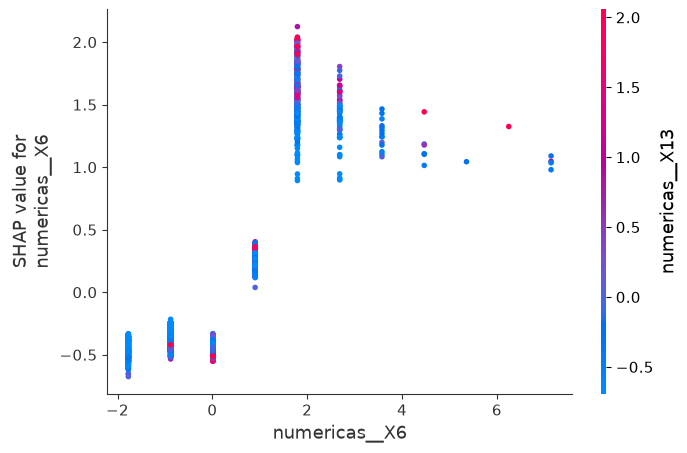

In [18]:
shap.dependence_plot(
    "numericas__X6",
    shap_values,
    X_test_transformado,
    feature_names=nomes_features
)

vealores baixos de X6 (entre -2 e 0) têm um impacto negativo na previsão (valores SHAP em torno de -0.5). Conforme X6 aumenta e passa de 1, o seu impacto se torna fortemente positivo, saltando para valores SHAP entre 1.0 e 2.0.

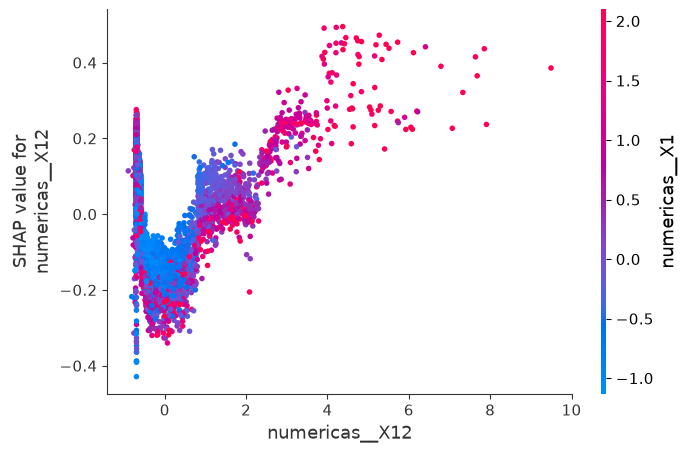

In [19]:
shap.dependence_plot(
    "numericas__X12",
    shap_values,
    X_test_transformado,
    feature_names=nomes_features
)

e possivel verificar de x12 entre -0.5 e 0 sofrem grande intereferencia quanto a presença da variavel x1  onde valores maiores de x1 combinados com tendem a aumentar o shap no modelo 

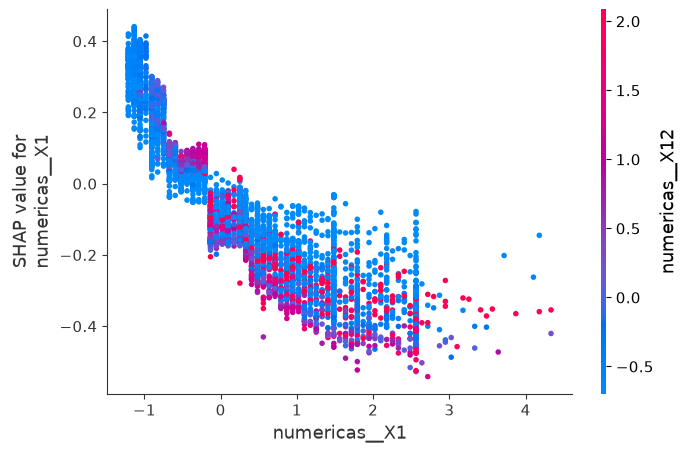

In [21]:
shap.dependence_plot(
    "numericas__X1",
    shap_values,
    X_test_transformado,
    feature_names=nomes_features
)

valores menores de x1 entre -1 e 0 tendem a produzir um shap positivo e a medida que o valor aumenta o shap tende a diminui os maiores valores de x1 geram um shap inferior a -0.4

### verificaçao dos falsos positivos 


In [27]:
y_real = y_test.squeeze()

# Índices dos quatro tipos
idx_tn = y_real.index[(y_real == 0) & (y_pred_otimo == 0)]
idx_fp = y_real.index[(y_real == 0) & (y_pred_otimo == 1)]
idx_fn = y_real.index[(y_real == 1) & (y_pred_otimo == 0)]
idx_tp = y_real.index[(y_real == 1) & (y_pred_otimo == 1)]

print("TN:", len(idx_tn))
print("FP:", len(idx_fp))
print("FN:", len(idx_fn))
print("TP:", len(idx_tp))

resultado = np.where(
    (y_real == 0) & (y_pred_otimo == 0), "TN",
    np.where(
        (y_real == 0) & (y_pred_otimo == 1), "FP",
        np.where(
            (y_real == 1) & (y_pred_otimo == 0), "FN",
            "TP"
        )
    )
)

df_erros = X_test.copy()

df_erros["real"] = y_real
df_erros["previsao"] = y_pred_otimo
df_erros["resultado"] = resultado
df_erros["probabilidade"] = y_prob_xgb

display(df_erros.head())

display(
    df_erros.groupby("resultado")[["X1", "X5", "X6", "X12", "X18"]]
    .mean()
)

TN: 2394
FP: 2273
FN: 232
TP: 1094


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X18,X19,X20,X21,X22,X23,real,previsao,resultado,probabilidade
8687,50000,2,3,1,43,0,0,0,0,0,...,2000,1500,3500,600,500,4000,0,1,FP,0.364179
24201,240000,1,2,1,31,0,0,0,0,0,...,7648,7900,8000,6500,6900,7000,0,0,TN,0.255886
27782,90000,2,1,2,25,0,0,0,0,0,...,1500,1500,1500,2000,1500,1000,0,1,FP,0.377681
14947,50000,2,2,2,22,0,0,2,0,0,...,4809,0,1200,1500,943,1142,0,1,FP,0.489564
1486,230000,1,1,2,32,0,0,0,0,0,...,10120,20000,10000,5000,5000,5000,0,0,TN,0.103251


,X1,X5,X6,X12,X18
resultado,,,,,
FN,215560.344828,36.008621,-0.469828,84847.250000,9207.853448
FP,126278.046634,35.338759,-0.003960,33220.378795,2632.702156
TN,227531.328321,35.485380,-0.445698,68969.271512,9844.313701
TP,114981.718464,36.256856,0.892139,43263.617916,2490.530165


### falsos negativos

In [28]:
falsos_negativos = df_erros[
    df_erros["resultado"] == "FN"
]

display(falsos_negativos.head(20))


display(
    falsos_negativos[
        ["X1", "X2", "X3", "X4", "X5",
         "X6", "X7", "X8", "X9", "X10", "X11",
         "X12", "X13", "X14", "X15", "X16", "X17",
         "X18", "X19", "X20", "X21", "X22", "X23","probabilidade"]
    ].describe()
)

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X18,X19,X20,X21,X22,X23,real,previsao,resultado,probabilidade
1071,150000,2,2,1,44,-1,-1,-1,-1,-1,...,5104,10318,10355,14441,780,66950,1,0,FN,0.221531
16110,200000,2,2,1,33,0,0,0,0,0,...,2034,3000,2083,10000,0,1286,1,0,FN,0.219716
29584,500000,1,3,1,39,0,-1,-1,-1,-1,...,1832,1920,21734,1837,0,19637,1,0,FN,0.187805
19474,270000,2,2,1,33,-1,-1,2,-1,0,...,2228,0,48546,2000,3000,3000,1,0,FN,0.335140
11543,260000,1,1,1,36,0,0,0,0,0,...,9029,9000,7100,7509,8000,6888,1,0,FN,0.288714
19584,310000,2,1,2,35,0,0,0,0,0,...,13088,9834,9500,9700,20200,11000,1,0,FN,0.330990
20767,400000,1,2,1,42,0,-1,-1,0,0,...,3369,8379,1074,124,3042,2891,1,0,FN,0.277495
1843,20000,1,1,2,41,-2,-2,0,0,0,...,36147,1281,658,1000,1000,760,1,0,FN,0.287053
17136,130000,2,3,2,24,0,0,0,0,0,...,4200,4500,5000,3600,25000,5000,1,0,FN,0.258169
22280,220000,2,1,2,29,0,0,0,0,0,...,9100,9000,7887,4800,4900,6000,1,0,FN,0.236630


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,probabilidade
count,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,...,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000,232.000000
mean,215560.344828,1.581897,1.836207,1.530172,36.008621,-0.469828,-0.508621,-0.413793,-0.474138,-0.435345,...,67216.607759,61568.012931,59374.650862,9207.853448,7515.728448,6059.543103,9599.241379,5855.224138,8307.435345,0.262262
std,126974.912394,0.494314,0.772290,0.525492,9.006006,0.737930,0.714666,0.811913,0.749732,0.786879,...,81298.695808,71445.527391,71041.594836,18722.148711,14752.831670,8647.771253,31324.055327,14379.033242,23253.000487,0.059414
min,20000.000000,1.000000,1.000000,1.000000,22.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-868.000000,-2710.000000,-1087.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.053482
25%,110000.000000,1.000000,1.000000,1.000000,29.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,6315.000000,5903.000000,4312.750000,2224.250000,2000.000000,1870.750000,2000.000000,1211.250000,1349.250000,0.224410
50%,200000.000000,2.000000,2.000000,2.000000,35.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,37833.000000,40350.000000,35247.500000,4506.000000,4124.000000,3463.500000,3550.000000,3000.000000,3000.000000,0.273140
75%,292500.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,101663.000000,97122.500000,98065.250000,9046.750000,8001.250000,6006.250000,6104.000000,5419.500000,5749.000000,0.310516
max,630000.000000,2.000000,4.000000,3.000000,66.000000,1.000000,0.000000,2.000000,2.000000,2.000000,...,514249.000000,462666.000000,472480.000000,175100.000000,149654.000000,65825.000000,432130.000000,194541.000000,200655.000000,0.339524


#### falso negativo

Índice: 1071
Probabilidade: 0.22153057
Real: 1
Previsão: 0
Exemplo de Falso Negativo


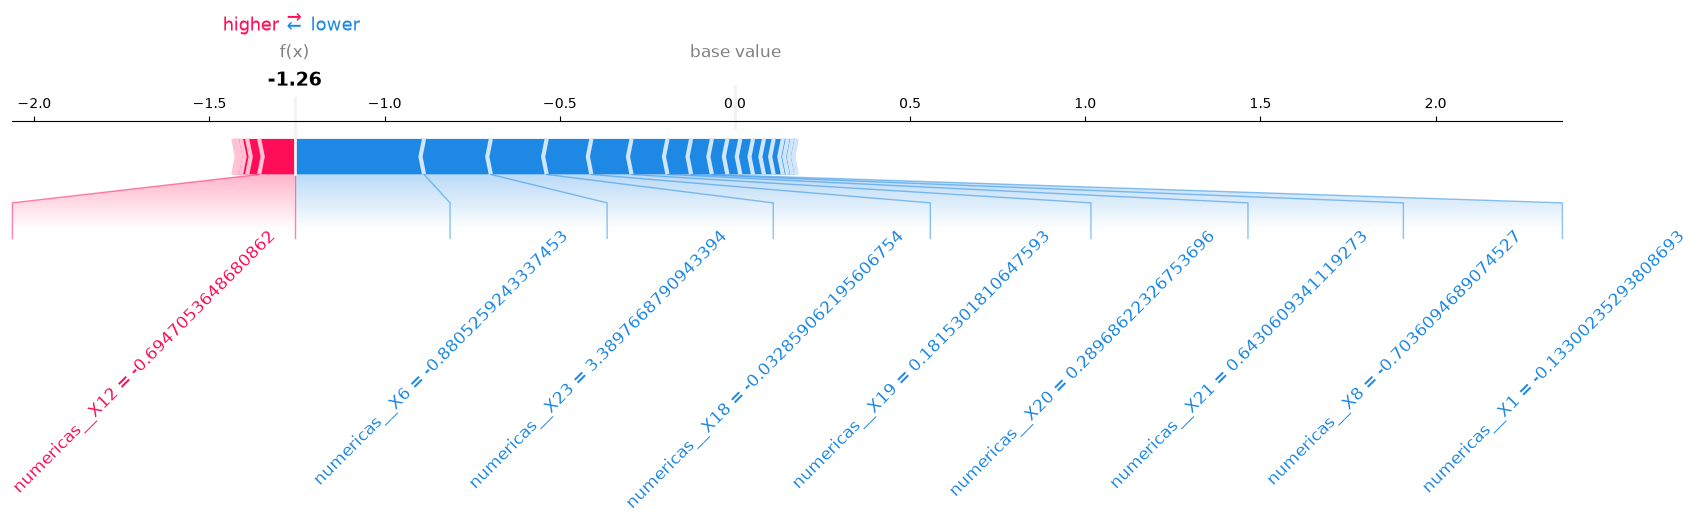

In [36]:
indice = idx_fn[0]

posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])


print ("Exemplo de Falso Negativo")
shap.force_plot(
    explainer.expected_value,
    shap_values[posicao],
    X_test_transformado[posicao],
    feature_names=nomes_features,
    matplotlib=True,
    text_rotation=45,
)

#### verdadeiro positivo

Índice: 29080
Probabilidade: 0.558015
Real: 1
Previsão: 1
Exemplo de verdadeiro Positivo


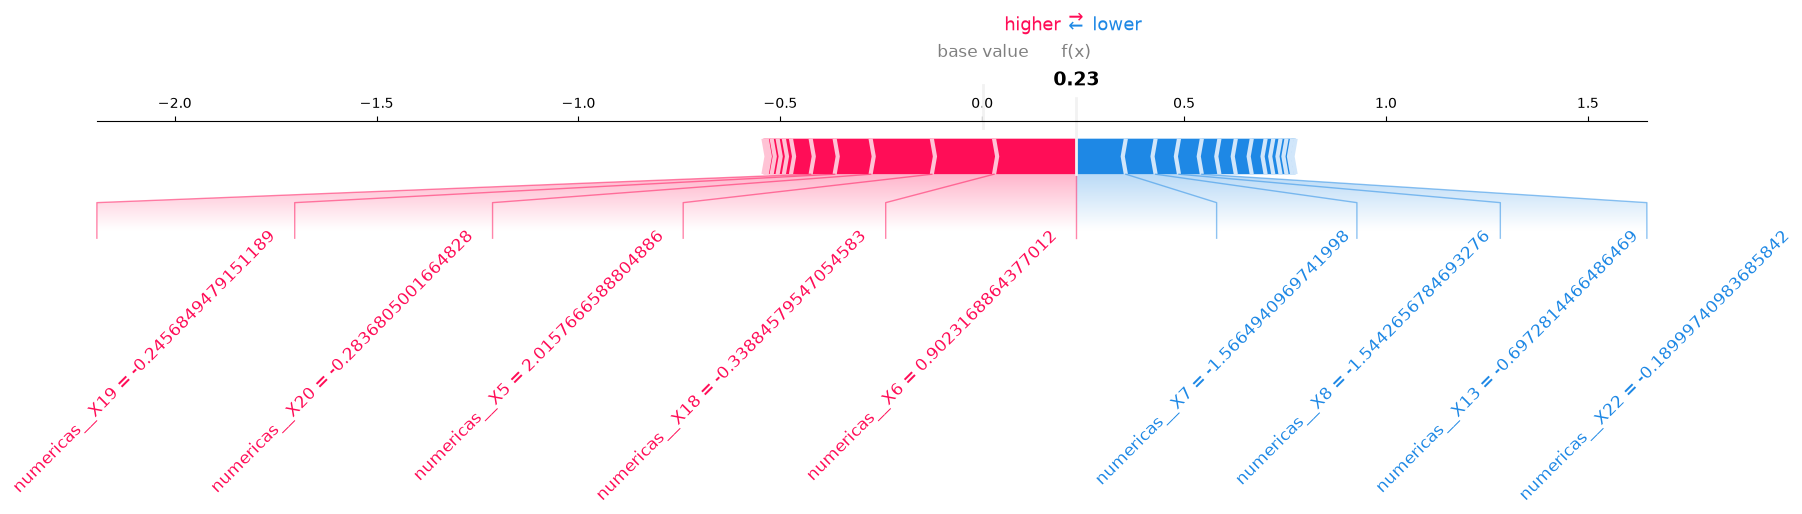

In [37]:
indice = idx_tp[0]

posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])


print ("Exemplo de verdadeiro Positivo")
shap.force_plot(
    explainer.expected_value,
    shap_values[posicao],
    X_test_transformado[posicao],
    feature_names=nomes_features,
    matplotlib=True,
    text_rotation=45,
)

#### falso positivo:

Índice: 8687
Probabilidade: 0.36417907
Real: 0
Previsão: 1
Exemplo de Falso Positivo


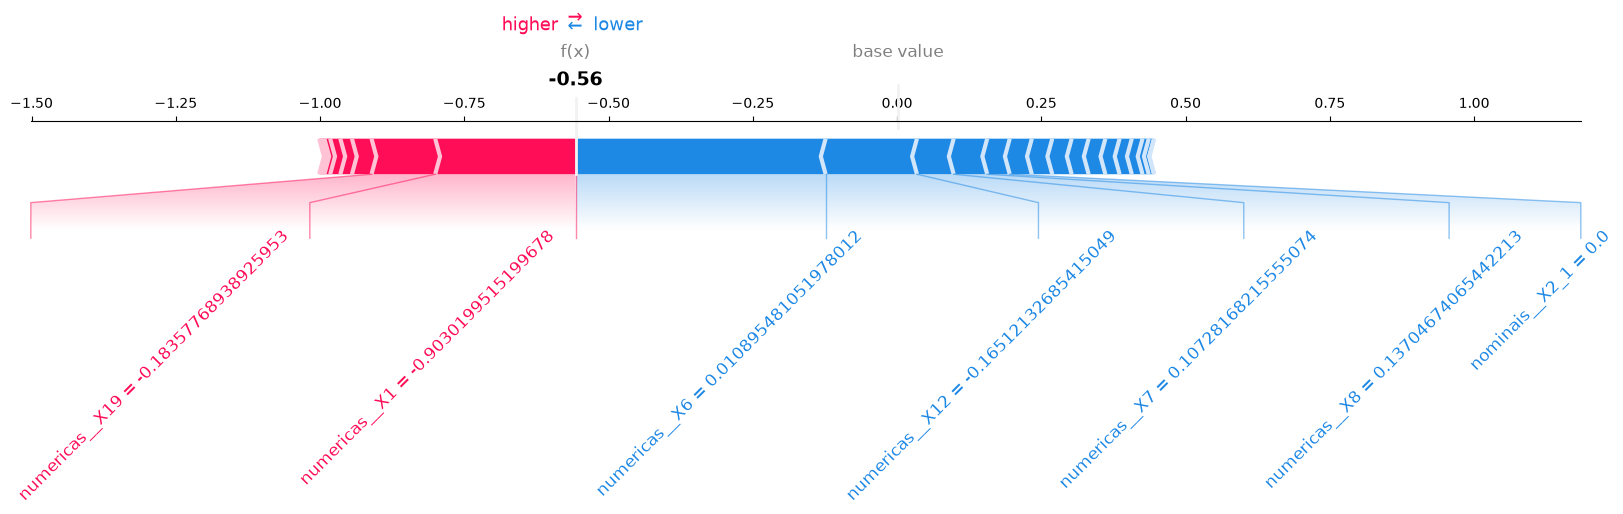

In [38]:
indice = idx_fp[0]

posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])


print ("Exemplo de Falso Positivo")
shap.force_plot(
    explainer.expected_value,
    shap_values[posicao],
    X_test_transformado[posicao],
    feature_names=nomes_features,
    matplotlib=True,
    text_rotation=45,
)

#### verdadeiro negativo

Índice: 24201
Probabilidade: 0.25588563
Real: 0
Previsão: 0
Exemplo de Verdadeiro Negativo


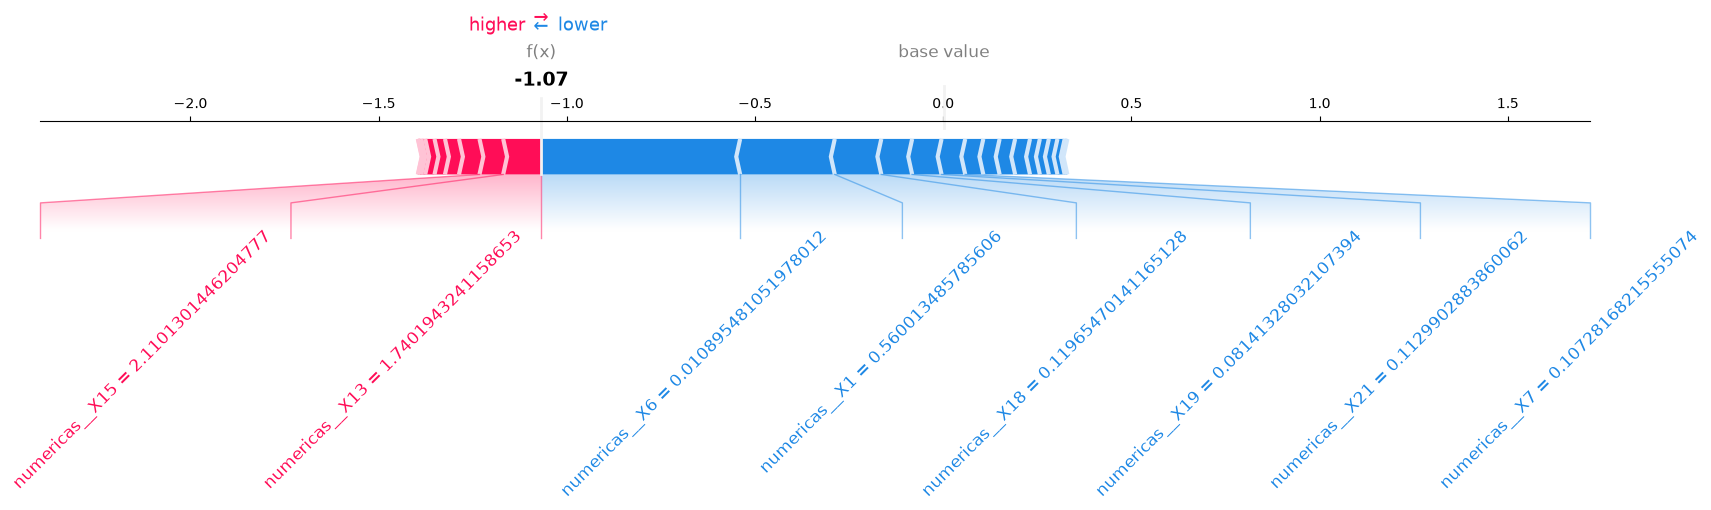

In [39]:
indice = idx_tn[0]

posicao = y_test.index.get_loc(indice)

print("Índice:", indice)
print("Probabilidade:", y_prob_xgb[posicao])
print("Real:", y_real.loc[indice])
print("Previsão:", y_pred_otimo[posicao])


print ("Exemplo de Verdadeiro Negativo")
shap.force_plot(
    explainer.expected_value,
    shap_values[posicao],
    X_test_transformado[posicao],
    feature_names=nomes_features,
    matplotlib=True,
    text_rotation=45,
)